In [1]:
import pandas as pd 
import miceforest as mf
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV
import seaborn as sns
import numpy as np

In [2]:
data = pd.read_csv("Quality_of_Life_final.csv")

missing_data_percentage = (data.isna().mean() * 100).round(2)

print(missing_data_percentage)

Country                                                       0.00
Year                                                          0.00
LE_at_birth                                                   6.83
Doctors_Per_10000                                            67.91
Access_to_Electricity                                        47.84
Unnamed: 0.3                                                 57.81
Unnamed: 0.2                                                 57.81
Unnamed: 0.1                                                 57.81
Unnamed: 0                                                   57.81
Carbon dioxide emissions per capita (production) (tonnes)    57.84
Gender Development Index                                     66.47
Gender Inequality Index                                      66.50
Human Development Index                                      61.83
Inequality-adjusted Human Development Index                  88.11
Planetary pressures-adjusted Human Development Index         6

In [3]:
data_1991 = data[data['Year'] >= 1991]

null_percentage_1991 = (data_1991.isna().mean() * 100).round(2)

print(null_percentage_1991)

Country                                                       0.00
Year                                                          0.00
LE_at_birth                                                  10.33
Doctors_Per_10000                                            63.16
Access_to_Electricity                                        18.44
Unnamed: 0.3                                                 35.13
Unnamed: 0.2                                                 35.13
Unnamed: 0.1                                                 35.13
Unnamed: 0                                                   35.13
Carbon dioxide emissions per capita (production) (tonnes)    35.17
Gender Development Index                                     48.03
Gender Inequality Index                                      48.27
Human Development Index                                      41.00
Inequality-adjusted Human Development Index                  81.14
Planetary pressures-adjusted Human Development Index         5

In [4]:
base_data = data_1991[['LE_at_birth', 'Access_to_Electricity', 'Gender Development Index','Human Development Index','Gender Inequality Index']].dropna()

base_data.to_csv("synthetic_data_healthcare_full.csv",index = False)

np.random.seed(76)
remove_percentage = 0.3

total_values = base_data.shape[0]
num_values_to_remove = int(remove_percentage * total_values)

nan_indices_le_at_birth = np.random.choice(base_data.index, num_values_to_remove, replace=False)
nan_indices_access_to_electricity = np.random.choice(base_data.index, num_values_to_remove, replace=False)
nan_indices_gender_dev_index = np.random.choice(base_data.index, num_values_to_remove, replace=False)
nan_indices_human_dev_index = np.random.choice(base_data.index, num_values_to_remove, replace=False)
nan_indices_gender_ineq_index = np.random.choice(base_data.index, num_values_to_remove, replace=False)

base_data.loc[nan_indices_le_at_birth, 'LE_at_birth'] = np.nan
base_data.loc[nan_indices_access_to_electricity, 'Access_to_Electricity'] = np.nan
base_data.loc[nan_indices_gender_dev_index, 'Gender Development Index'] = np.nan
base_data.loc[nan_indices_human_dev_index, 'Human Development Index'] = np.nan
base_data.loc[nan_indices_gender_ineq_index, 'Gender Inequality Index'] = np.nan

base_data.to_csv("synthetic_data_healthcare.csv", index=False)

In [5]:
data_imputation = pd.read_csv("synthetic_data_healthcare.csv")

kernel = mf.ImputationKernel(
    data_imputation,
    num_datasets = 1,
    mean_match_candidates=0,
    random_state = 28
    )

optimal_params = kernel.tune_parameters(
    dataset=0, 
    use_gbdt=True,
    num_iterations=500,
    random_state=1,
)
kernel.mice(1, variable_parameters=optimal_params)
pd.DataFrame(optimal_params)

,LE_at_birth,Access_to_Electricity,Gender Development Index,Human Development Index,Gender Inequality Index
boosting,gbdt,gbdt,gbdt,gbdt,gbdt
data_sample_strategy,bagging,bagging,bagging,bagging,bagging
num_iterations,266,241,287,217,286
max_depth,4,4,4,5,3
num_leaves,12,17,11,18,18
min_data_in_leaf,4,6,1,1,48
min_sum_hessian_in_leaf,0.01,0.01,0.01,0.01,0.01
min_gain_to_split,0.0,0.0,0.0,0.0,0.0
bagging_fraction,0.580973,0.501521,0.582307,0.779917,0.484219
feature_fraction_bynode,0.922566,0.299912,0.697415,0.778489,0.776686


In [6]:
kernel.mice(30,variable_parameters=optimal_params)
imputed_data = kernel.complete_data(0)

imputed_data.to_csv("synthetic_data_healthcare_imputed.csv", index=False)

In [7]:
synthetic_data_full = pd.read_csv('synthetic_data_healthcare_full.csv')
imputed_synthetic_data = pd.read_csv('synthetic_data_healthcare_imputed.csv')

columns_to_evaluate = ['LE_at_birth', 'Access_to_Electricity', 'Gender Development Index','Human Development Index','Gender Inequality Index']

r2_results = {}
rmse_results = {}
mae_results = {}

for column in columns_to_evaluate:
    original_values = synthetic_data_full[column]
    imputed_values = imputed_synthetic_data[column]

    missing_indices = original_values.isna()
    original_values_non_missing = original_values[~missing_indices]
    imputed_values_non_missing = imputed_values[~missing_indices]

    r2 = r2_score(original_values_non_missing, imputed_values_non_missing)
    r2_results[column] = round(r2, 2)

    rmse = np.sqrt(mean_squared_error(original_values_non_missing, imputed_values_non_missing))
    rmse_results[column] = round(rmse, 2)

    mae = mean_absolute_error(original_values_non_missing, imputed_values_non_missing)
    mae_results[column] = round(mae, 2)

print("R² Scores:")
print(r2_results)

print("\nRMSE Scores:")
print(rmse_results)

print("\nMAE Scores:")
print(mae_results)

R² Scores:
{'LE_at_birth': 0.95, 'Access_to_Electricity': 0.95, 'Gender Development Index': 0.88, 'Human Development Index': 0.96, 'Gender Inequality Index': 0.94}

RMSE Scores:
{'LE_at_birth': 2.06, 'Access_to_Electricity': 7.04, 'Gender Development Index': 0.02, 'Human Development Index': 0.03, 'Gender Inequality Index': 0.05}

MAE Scores:
{'LE_at_birth': 0.8, 'Access_to_Electricity': 2.01, 'Gender Development Index': 0.01, 'Human Development Index': 0.01, 'Gender Inequality Index': 0.02}


In [8]:
import random

original_data = pd.read_csv('synthetic_data_healthcare_full.csv')

columns_to_evaluate = ['LE_at_birth', 'Access_to_Electricity', 'Gender Development Index','Human Development Index','Gender Inequality Index']

# Initialize dictionaries to store metrics across iterations
r2_results = {col: [] for col in columns_to_evaluate}
rmse_results = {col: [] for col in columns_to_evaluate}
mae_results = {col: [] for col in columns_to_evaluate}

# Parameters for random NaN generation
remove_percentage = 0.3
num_iterations = 30

# Optimal parameters for miceforest
optimal_params = {
    # Define optimal parameters here
}

# Run the evaluation over multiple iterations with random NaN values
for i in range(num_iterations):
    # Create a new copy of the data to introduce NaN values each time
    data = original_data.copy()
    
    # Randomly introduce NaN values in each column for each iteration
    for column in columns_to_evaluate:
        num_missing = int(remove_percentage * data[column].dropna().shape[0])
        nan_indices = random.sample(list(data[column].dropna().index), num_missing)
        data.loc[nan_indices, column] = np.nan
    
    # Initialize the MICE kernel and perform imputation with optimal parameters
    kernel = mf.ImputationKernel(data, num_datasets=1, random_state=34)
    kernel.mice(1, variable_parameters=optimal_params)
    
    # Complete the dataset and save it
    imputed_data = kernel.complete_data(0)
    imputed_data.to_csv("synthetic_data_QOLI_imputed.csv", index=False)
    
    # Calculate metrics for each column
    for column in columns_to_evaluate:
        original_values = original_data[column]
        imputed_values = imputed_data[column]

        # Identify non-missing indices in the original dataset
        missing_indices = original_values.isna()
        original_values_non_missing = original_values[~missing_indices]
        imputed_values_non_missing = imputed_values[~missing_indices]

        # R² score
        r2 = r2_score(original_values_non_missing, imputed_values_non_missing)
        r2_results[column].append(r2)

        # RMSE
        rmse = np.sqrt(mean_squared_error(original_values_non_missing, imputed_values_non_missing))
        rmse_results[column].append(rmse)

        # MAE
        mae = mean_absolute_error(original_values_non_missing, imputed_values_non_missing)
        mae_results[column].append(mae)

# Calculate mean and standard deviation of metrics across iterations
metrics_summary = {
    "Metric": [],
    "Column": [],
    "Mean Value": [],
    "Standard Deviation": []
}

# Aggregate results for R², RMSE, and MAE
for column in columns_to_evaluate:
    for metric, values_dict in zip(["R²", "RMSE", "MAE"], [r2_results, rmse_results, mae_results]):
        mean_val = np.mean(values_dict[column])
        std_dev = np.std(values_dict[column])
        
        metrics_summary["Metric"].append(metric)
        metrics_summary["Column"].append(column)
        metrics_summary["Mean Value"].append(round(mean_val, 2))
        metrics_summary["Standard Deviation"].append(round(std_dev, 4))

# Convert summary to a DataFrame and display
metrics_summary_df = pd.DataFrame(metrics_summary)
print(metrics_summary_df)


   Metric                    Column  Mean Value  Standard Deviation
0      R²               LE_at_birth        0.85              0.0081
1    RMSE               LE_at_birth        3.56              0.0984
2     MAE               LE_at_birth        1.40              0.0367
3      R²     Access_to_Electricity        0.87              0.0078
4    RMSE     Access_to_Electricity       11.38              0.3362
5     MAE     Access_to_Electricity        3.38              0.1284
6      R²  Gender Development Index        0.78              0.0106
7    RMSE  Gender Development Index        0.03              0.0008
8     MAE  Gender Development Index        0.01              0.0003
9      R²   Human Development Index        0.89              0.0048
10   RMSE   Human Development Index        0.06              0.0012
11    MAE   Human Development Index        0.02              0.0004
12     R²   Gender Inequality Index        0.85              0.0067
13   RMSE   Gender Inequality Index        0.08 

Fitting 3 folds for each of 30 candidates, totalling 90 fits
Best Parameters: {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 0.5, 'max_depth': None}


C:\Users\Admin\anaconda3\envs\Ease\Lib\site-packages\sklearn\impute\_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


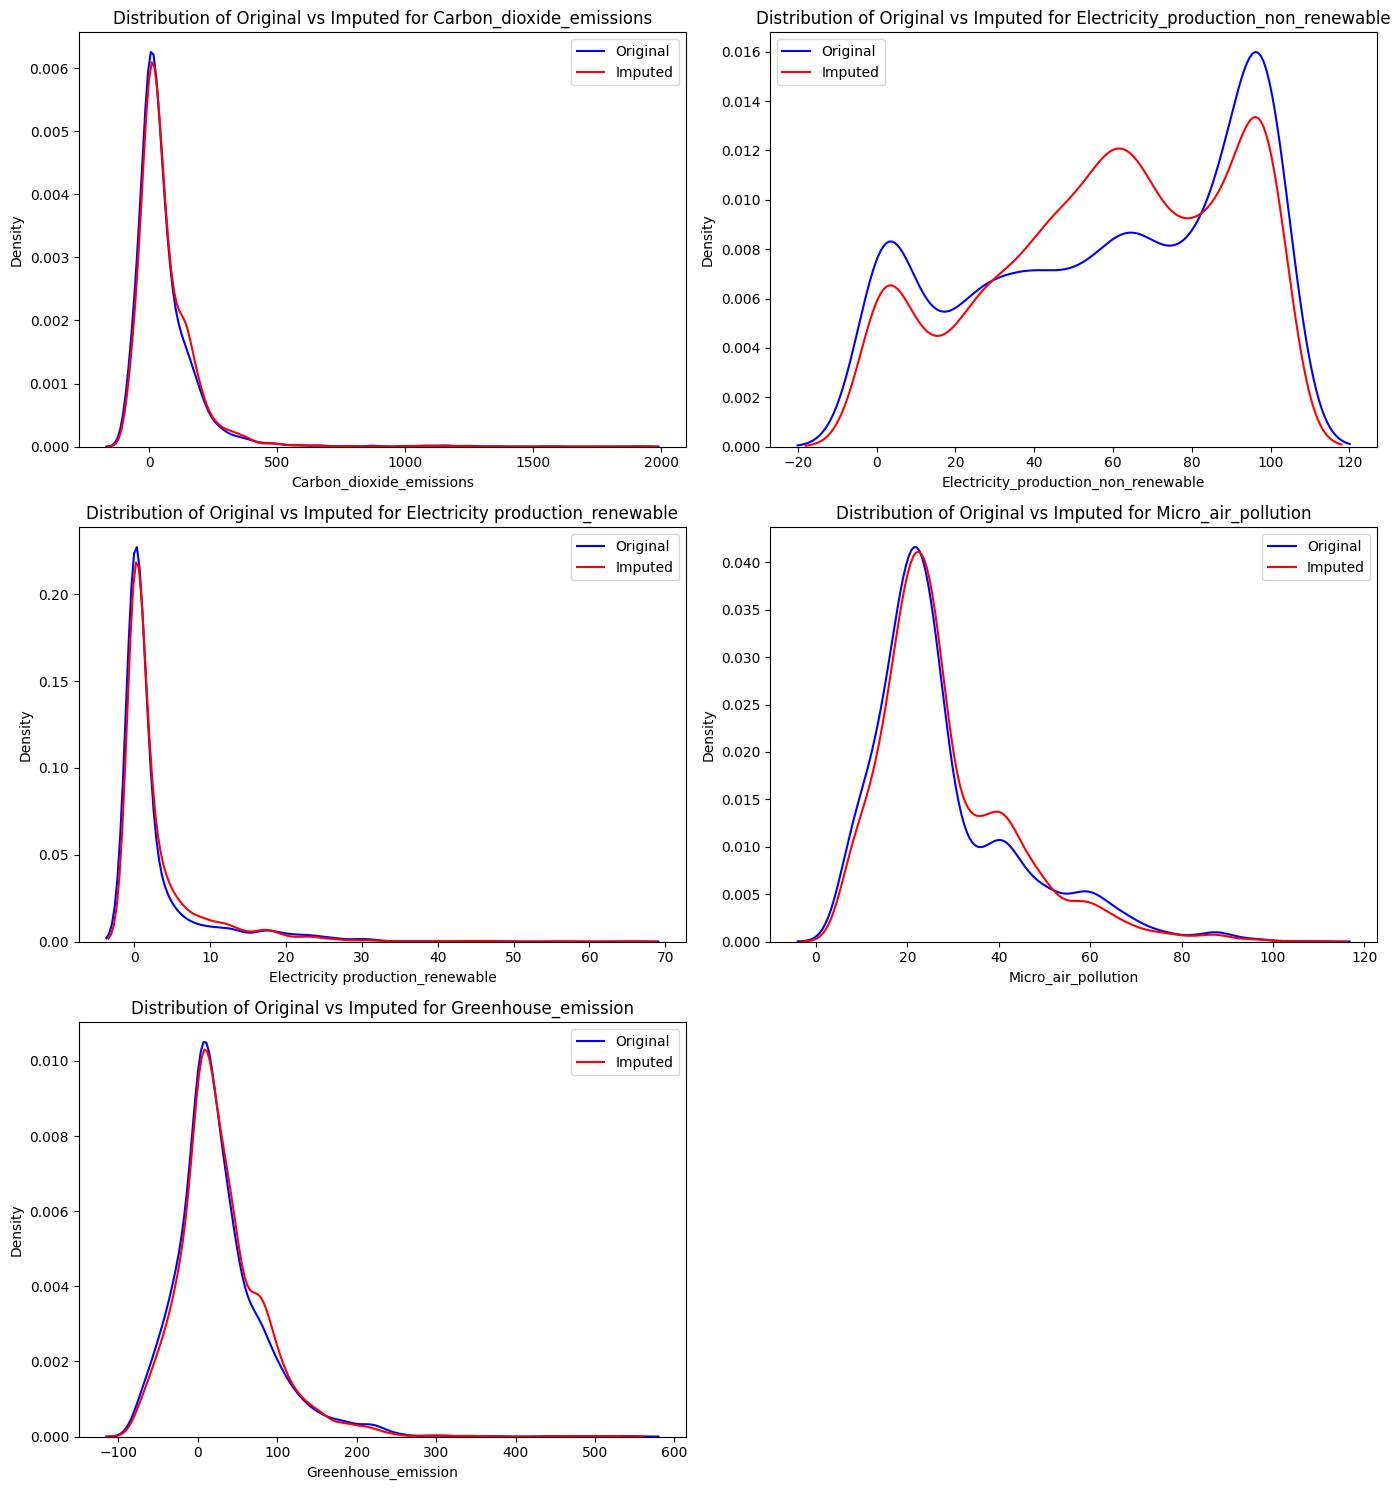

                                 target       R^2       RMSE        MAE
0              Carbon_dioxide_emissions  0.803275  57.387422  16.306501
1  Electricity_production_non_renewable  0.771766  16.247606   7.010219
2      Electricity production_renewable  0.748228   3.096109   0.987515
3                   Micro_air_pollution  0.763718   7.927619   3.101588
4                   Greenhouse_emission  0.826281  24.521051   7.842397


In [9]:
# Load data
synthetic_data = pd.read_csv('synthetic_data_sustainability.csv')
full_data = pd.read_csv('synthetic_data_sustainability_full.csv')

categorical_cols = full_data.select_dtypes(include=['object']).columns
label_encoders = {}
for col in categorical_cols:
    label_encoders[col] = LabelEncoder()
    data[col] = label_encoders[col].fit_transform(full_data[col].astype(str))
    
# Define hyperparameter grid for RandomForestRegressor
param_grid = {
    'n_estimators': [50, 100, 150, 200],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': [1, 0.5, 0.3]
}

rf = RandomForestRegressor(random_state=78)
random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_grid,
    n_iter=30,  # Number of parameter settings sampled
    scoring='neg_mean_squared_error',
    cv=3,
    verbose=1,
    random_state=78,
    n_jobs=-1
)

# Prepare data for tuning (use non-missing rows only)
X = full_data.dropna()
X_features = full_data.drop(columns=categorical_cols)

# Fit RandomizedSearchCV
random_search.fit(X_features, X_features)
best_params = random_search.best_params_
print("Best Parameters:", best_params)

# Configure and fit the imputer
rf_imputer = IterativeImputer(
    estimator=RandomForestRegressor(
        n_estimators=best_params['n_estimators'],
        max_depth=best_params['max_depth'],
        min_samples_split=best_params['min_samples_split'],
        min_samples_leaf=best_params['min_samples_leaf'],
        max_features=best_params['max_features'],
        random_state=29
    ),
    random_state=29
)
synthetic_data_imputed = pd.DataFrame(rf_imputer.fit_transform(synthetic_data), columns=synthetic_data.columns)

# Initialize metrics storage
metrics = {'target': [], 'R^2': [], 'RMSE': [], 'MAE': []}
missing_columns = synthetic_data.columns[synthetic_data.isnull().any()]

# Set up subplots
num_columns = len(missing_columns)
fig, axes = plt.subplots(nrows=num_columns // 2 + num_columns % 2, ncols=2, figsize=(14, num_columns * 3))
axes = axes.flatten()  # Flatten for easy indexing

# Loop through each column with missing values
for idx, column in enumerate(missing_columns):
    y_true = full_data[column]
    y_pred = synthetic_data_imputed[column]

    # Calculate metrics
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    
    # Append metrics for this target
    metrics['target'].append(column)
    metrics['R^2'].append(r2)
    metrics['RMSE'].append(rmse)
    metrics['MAE'].append(mae)
    
    # Plot distribution comparison in subplots
    sns.kdeplot(y_true, label='Original', color='blue', ax=axes[idx])
    sns.kdeplot(y_pred, label='Imputed', color='red', ax=axes[idx])
    axes[idx].set_title(f"Distribution of Original vs Imputed for {column}")
    axes[idx].set_xlabel(column)
    axes[idx].legend()

# Remove any unused subplots
for j in range(idx + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# Display metrics as a DataFrame
metrics_df = pd.DataFrame(metrics)
print(metrics_df)